In [1]:
import pandas as pd

In [6]:
kindel_review = pd.read_csv('all_kindle_review .csv')
preprocessed_review = pd.read_csv('preprocessed_kindle_review .csv')

In [7]:
kindel_review.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [9]:
kindel_review.shape

(12000, 11)

In [10]:
preprocessed_review.head()

,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [15]:
preprocessed_review['summary'].head(50)

0                                     50 + years ago...
1                               Boring! Boring! Boring!
2                       Wiggleliscious/new toy ready/!!
3                                       Very good read.
4                                          Great Story!
5     When an Alien Scientist Gets Lost in the Orego...
6           Hot Civil War Read... I wanted more Romance
7                   Wow and wonderful read with a twist
8                              Steadily getting better!
9                                      Childish writing
10                              Kiss... Kiss... Kiss :)
11                           I'm being kind with 1 star
12             Great Paper but would like a lower price
13                                          II Liked It
14                                           Lousy Read
15                                        unimaginative
16                   all heroes should be like this man
17                                         An ok

In [16]:
preprocessed_review.isnull().sum()

Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

In [17]:
df=kindel_review

In [19]:
# Best Practise
## Data cleaning and preprocessing
## Train and Test Split
## Bow, TL-IDF, Word2vec, Avgword2vec
## Train Ml Model and evualate the model

In [20]:
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [24]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText',
       'reviewTime', 'reviewerID', 'reviewerName', 'summary',
       'unixReviewTime'],
      dtype='str')

In [27]:
# choosing 2 important columns for text vectorization
df = df[[ 'rating', 'reviewText' ]]

In [28]:
df.head()

,rating,reviewText
0,3,"Jace Rankin may be short, but he's nothing to ..."
1,5,Great short read. I didn't want to put it dow...
2,3,I'll start by saying this is the first of four...
3,3,Aggie is Angela Lansbury who carries pocketboo...
4,4,I did not expect this type of book to be in li...


In [29]:
# Checking for missing values

df.isnull().sum()

rating        0
reviewText    0
dtype: int64

In [31]:
df.shape

(12000, 2)

In [33]:
# Checking for distribution rating for imbalances.

df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [34]:
## Preprocesssing and cleaning
### We are doing a sentiment analysis, so we will convert all the rating into binary classes. 1 for positive and 0 for negative.

In [45]:
# if rating is above 3 the it is positive and if below 3 then it is negative.
df['rating']=df['rating'].apply(lambda x: 1 if x>3 else 0)

In [47]:
# checking the disctribution of rating after encoding it to binary class.
df['rating'].value_counts()

rating
0    12000
Name: count, dtype: int64

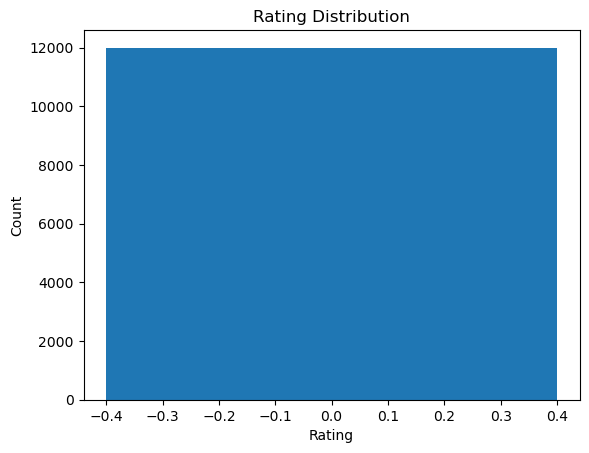

In [42]:
# ploting graph for distribution of rating

import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts().sort_index()

plt.figure()
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()